<a href="https://colab.research.google.com/github/marcovoc300/data2-usuarios-spotify/blob/main/entrega_data2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
import pandas as pd


In [2]:
from google.colab import files

In [3]:
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
df = pd.read_excel('/content/drive/MyDrive/data_science_2/entrega_data2/Spotify_data_español_2500_filas_ajustado.xlsx')
df.head()

,ID_Usuario,Rango_Edad,Genero,pais,Antiguedad_Uso_Spotify,Unnamed: 5,Plan_Suscripcion_Actual,Disposicion_Pagar_Premium,Plan_Premium_Preferido,Contenido_Preferido,Genero_Musical_Favorito,Franja_Horaria_de_uso,Valoracion_Musica,Frecuencia_Escucha_Podcast,Genero_Podcast_Favorito,Duracion_Podcast_Preferida,Satisfaccion_Variedad_Podcast
0,USR_00001,20-35,Masculino,Estados Unidos,Más de 2 años,Móvil,Premium (suscripción paga),Sí,Plan Individual,Música,Melódico / Baladas,Noche,5,Raramente,Comedia,Longer,Satisfecho
1,USR_00002,35-60,Masculino,Reino Unido,Más de 2 años,Móvil,Gratuito (con anuncios),No,NaN,Música,Pop,Noche,5,Raramente,Estilo de vida y Salud,Ambos,Satisfecho
2,USR_00003,20-35,Femenino,Estados Unidos,Más de 2 años,Móvil,Premium (suscripción paga),Sí,Plan Individual,Música,Pop,Noche,3,Raramente,Estilo de vida y Salud,Shorter,Aceptable / Regular
3,USR_00004,20-35,Femenino,España,De 1 año a 2 años,Móvil,Gratuito (con anuncios),No,Plan Individual,Música,Pop,Noche,4,Nunca,NaN,NaN,Aceptable / Regular
4,USR_00005,20-35,Femenino,México,Más de 2 años,Móvil,Premium (suscripción paga),Sí,Plan Individual,Música,Pop,Noche,5,Raramente,Comedia,Shorter,Satisfecho


In [9]:
# 1. Renombrar la columna 'Unnamed: 5' por posición explícita (índice 5)
df.columns.values[5] = 'Dispositivo_Escucha'

# 2. Limpiar espacios sobrantes en los nombres de todas las columnas
df.columns = df.columns.str.strip()

# 3. Mostrar la lista actualizada para verificar la corrección
print("--- COLUMNAS NORMALIZADAS ---")
for i, col in enumerate(df.columns):
    print(f"Índice {i}: {col}")

--- COLUMNAS NORMALIZADAS ---
Índice 0: ID_Usuario
Índice 1: Rango_Edad
Índice 2: Genero
Índice 3: pais
Índice 4: Antiguedad_Uso_Spotify
Índice 5: Dispositivo_Escucha
Índice 6: Plan_Suscripcion_Actual
Índice 7: Disposicion_Pagar_Premium
Índice 8: Plan_Premium_Preferido
Índice 9: Contenido_Preferido
Índice 10: Genero_Musical_Favorito
Índice 11: Franja_Horaria_de_uso
Índice 12: Valoracion_Musica
Índice 13: Frecuencia_Escucha_Podcast
Índice 14: Genero_Podcast_Favorito
Índice 15: Duracion_Podcast_Preferida
Índice 16: Satisfaccion_Variedad_Podcast


Paso 2: Filtrado del Universo Gratuito y Análisis de Disposición al Pago

Dado que la estrategia comercial busca maximizar los ingresos por publicidad (Ad-Tech) en usuarios que no convierten a planes de pago, se filtra el dataset para conservar únicamente a los usuarios con Plan_Suscripcion_Actual == 'Gratuito (con anuncios)'. Sobre este subconjunto se analiza la variable Disposicion_Pagar_Premium para cuantificar el volumen real de la audiencia cautiva para anunciantes.

In [10]:
# 1. Crear el DataFrame filtrado para usuarios del Plan Gratuito
df_free = df[df['Plan_Suscripcion_Actual'] == 'Gratuito (con anuncios)'].copy()

# 2. Calcular la distribución absoluta y porcentual de la disposición a pagar
conteo_pago = df_free['Disposicion_Pagar_Premium'].value_counts()
porcentaje_pago = df_free['Disposicion_Pagar_Premium'].value_counts(normalize=True) * 100

# 3. Presentar los resultados consolidados
resumen_pago = pd.DataFrame({
    'Cantidad_Usuarios': conteo_pago,
    'Porcentaje (%)': porcentaje_pago.round(2)
})

print(f"Total de usuarios en Plan Gratuito: {len(df_free)} ({len(df_free)/len(df)*100:.1f}% del total)\n")
print("--- DISPOSICIÓN A PAGAR EN USUARIOS GRATUITOS ---")
print(resumen_pago)

Total de usuarios en Plan Gratuito: 2027 (81.1% del total)

--- DISPOSICIÓN A PAGAR EN USUARIOS GRATUITOS ---
                           Cantidad_Usuarios  Porcentaje (%)
Disposicion_Pagar_Premium                                   
No                                      1470           72.52
Sí                                       557           27.48


/tmp/ipykernel_2506/3492896030.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


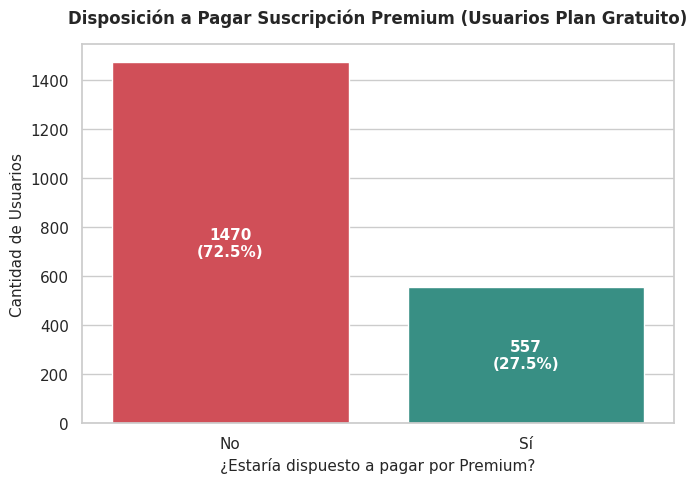

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configurar el estilo gráfico
sns.set_theme(style="whitegrid")
plt.figure(figsize=(7, 5))

# 2. Definir colores ejecutivos (Rojo para 'No' / Verde-Azul para 'Sí')
colores = ['#E63946', '#2A9D8F']

# 3. Crear el gráfico de barras
ax = sns.countplot(
    data=df_free,
    x='Disposicion_Pagar_Premium',
    order=['No', 'Sí'],
    palette=colores
)

# 4. Títulos y etiquetas de ejes
plt.title('Disposición a Pagar Suscripción Premium (Usuarios Plan Gratuito)', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('¿Estaría dispuesto a pagar por Premium?', fontsize=11)
plt.ylabel('Cantidad de Usuarios', fontsize=11)

# 5. Agregar valores absolutos y porcentajes dentro de las barras
total_usuarios = len(df_free)
for p in ax.patches:
    altura = p.get_height()
    porcentaje = (altura / total_usuarios) * 100
    ax.annotate(f'{int(altura)}\n({porcentaje:.1f}%)',
                (p.get_x() + p.get_width() / 2., altura / 2),
                ha='center', va='center',
                fontsize=11, color='white', fontweight='bold')

plt.tight_layout()
plt.show()

Paso 3: Perfilado Demográfico de la Audiencia Gratuita (Rango_Edad y pais)

Una vez identificado que el 72,5% de los usuarios del plan gratuito no migrarán a planes de pago, se procede a caracterizar la estructura demográfica de este universo (2.027 usuarios).   
El objetivo de este análisis es determinar la concentración etaria (Rango_Edad) y la distribución geográfica (pais) de los usuarios expuestos a pauta publicitaria, evaluando si la audiencia representa un perfil joven-adulto de alto interés comercial para anunciantes.


/tmp/ipykernel_2506/2011412358.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.countplot(
/tmp/ipykernel_2506/2011412358.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.barplot(


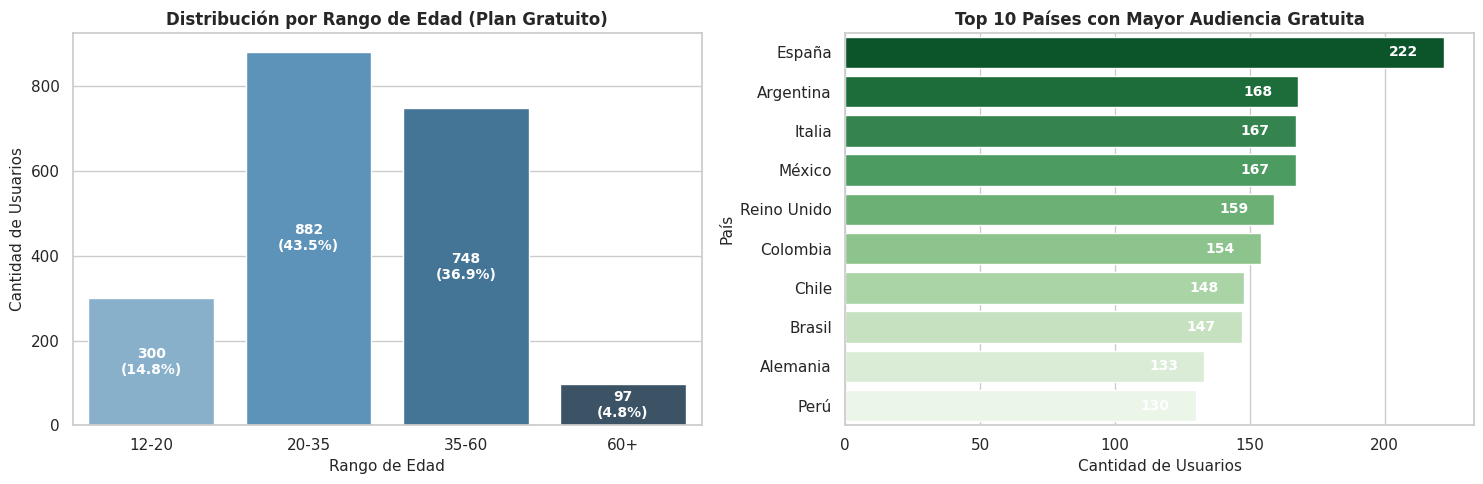

In [12]:
# 1. Configuración de estilo visual
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 2. Gráfico A: Distribución por Rango de Edad en Usuarios Gratuitos
orden_edad = ['12-20', '20-35', '35-60', '60+']
ax1 = sns.countplot(
    data=df_free,
    x='Rango_Edad',
    order=orden_edad,
    palette='Blues_d',
    ax=axes[0]
)
axes[0].set_title('Distribución por Rango de Edad (Plan Gratuito)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Rango de Edad', fontsize=11)
axes[0].set_ylabel('Cantidad de Usuarios', fontsize=11)

# Agregar etiquetas de porcentaje en barras de Edad
total_free = len(df_free)
for p in ax1.patches:
    altura = p.get_height()
    porcentaje = (altura / total_free) * 100
    ax1.annotate(f'{int(altura)}\n({porcentaje:.1f}%)',
                 (p.get_x() + p.get_width() / 2., altura / 2),
                 ha='center', va='center',
                 fontsize=10, color='white', fontweight='bold')

# 3. Gráfico B: Top 10 Países con Mayor Concentración de Usuarios Gratuitos
top_paises = df_free['pais'].value_counts().head(10)
ax2 = sns.barplot(
    x=top_paises.values,
    y=top_paises.index,
    palette='Greens_r',
    ax=axes[1]
)
axes[1].set_title('Top 10 Países con Mayor Audiencia Gratuita', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Cantidad de Usuarios', fontsize=11)
axes[1].set_ylabel('País', fontsize=11)

# Agregar etiquetas numéricas en las barras de País
for p in ax2.patches:
    ancho = p.get_width()
    ax2.annotate(f'{int(ancho)}',
                 (ancho - 15, p.get_y() + p.get_height() / 2.),
                 ha='center', va='center',
                 fontsize=10, color='white', fontweight='bold')

plt.tight_layout()
plt.show()

Paso 4: Análisis Bivariado de Hábitos de Consumo (Contenido_Preferido y Dispositivo_Escucha)

Para diseñar una pauta publicitaria eficiente, la segmentación geográfica y etaria debe complementarse con el comportamiento de escucha. En este paso se examina la preferencia entre Música vs. Pódcast a través de los diferentes rangos etarios, así como la distribución del Dispositivo de Escucha (Móvil, Computadora, etc.).   
PNG
El objetivo es identificar las plataformas de mayor alcance y determinar si el consumo de pódcast se concentra en algún grupo etario específico para campañas de audio digital focalizadas.

/tmp/ipykernel_2506/2214872539.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


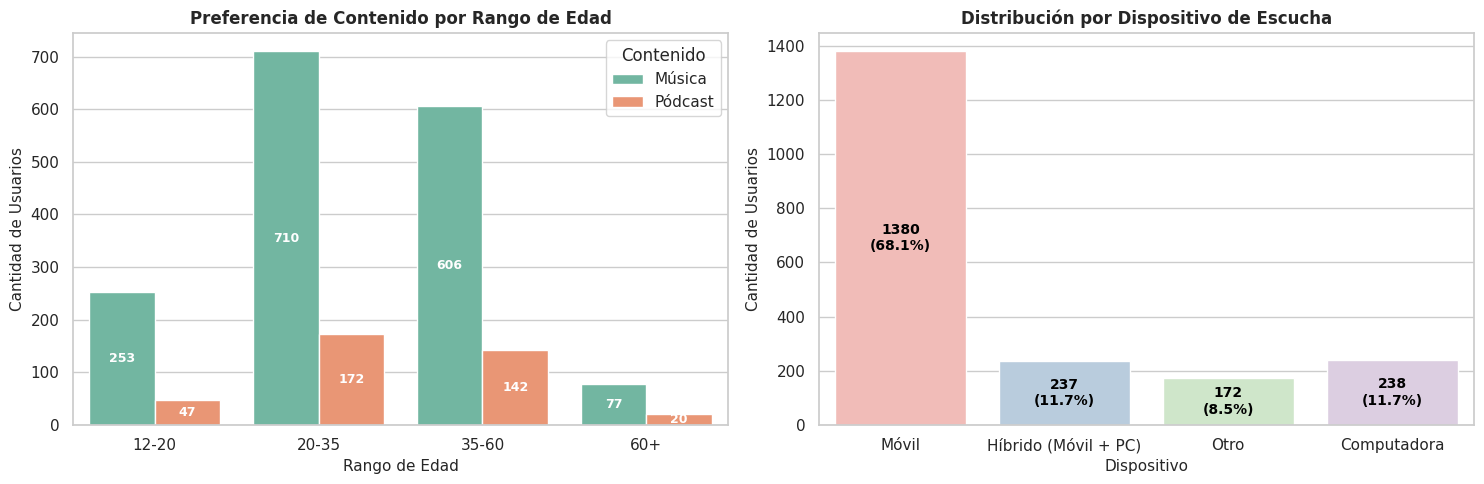

In [13]:
# 1. Configurar panel de visualización doble
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 2. Gráfico A: Contenido Preferido según Rango de Edad
sns.countplot(
    data=df_free,
    x='Rango_Edad',
    hue='Contenido_Preferido',
    order=['12-20', '20-35', '35-60', '60+'],
    palette='Set2',
    ax=axes[0]
)
axes[0].set_title('Preferencia de Contenido por Rango de Edad', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Rango de Edad', fontsize=11)
axes[0].set_ylabel('Cantidad de Usuarios', fontsize=11)
axes[0].legend(title='Contenido', frameon=True)

# Agregar etiquetas sobre las barras
for p in axes[0].patches:
    altura = p.get_height()
    if altura > 0:
        axes[0].annotate(f'{int(altura)}',
                         (p.get_x() + p.get_width() / 2., altura / 2),
                         ha='center', va='center',
                         fontsize=9, color='white', fontweight='bold')

# 3. Gráfico B: Distribución por Dispositivo de Escucha
sns.countplot(
    data=df_free,
    x='Dispositivo_Escucha',
    palette='Pastel1',
    ax=axes[1]
)
axes[1].set_title('Distribución por Dispositivo de Escucha', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Dispositivo', fontsize=11)
axes[1].set_ylabel('Cantidad de Usuarios', fontsize=11)

# Agregar valores numéricos y porcentajes en Dispositivo
total_free = len(df_free)
for p in axes[1].patches:
    altura = p.get_height()
    porcentaje = (altura / total_free) * 100
    axes[1].annotate(f'{int(altura)}\n({porcentaje:.1f}%)',
                     (p.get_x() + p.get_width() / 2., altura / 2),
                     ha='center', va='center',
                     fontsize=10, color='black', fontweight='bold')

plt.tight_layout()
plt.show()

Paso 5: Caracterización de Contenidos Preferidos en Música y Pódcasts

Para personalizar la pauta publicitaria y definir la afinidad de marca (ej. auspiciantes de salud, entretenimiento o finanzas), se analiza la distribución de los géneros musicales favoritos (Genero_Musical_Favorito) y las temáticas predilectas en pódcasts (Genero_Podcast_Favorito) dentro de los usuarios del plan gratuito.   
Este desglose permite identificar los nichos temáticos de mayor volumen para pauta geolocalizada o contextualizada según el interés del oyente.

/tmp/ipykernel_2506/1631855404.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(
/tmp/ipykernel_2506/1631855404.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.barplot(


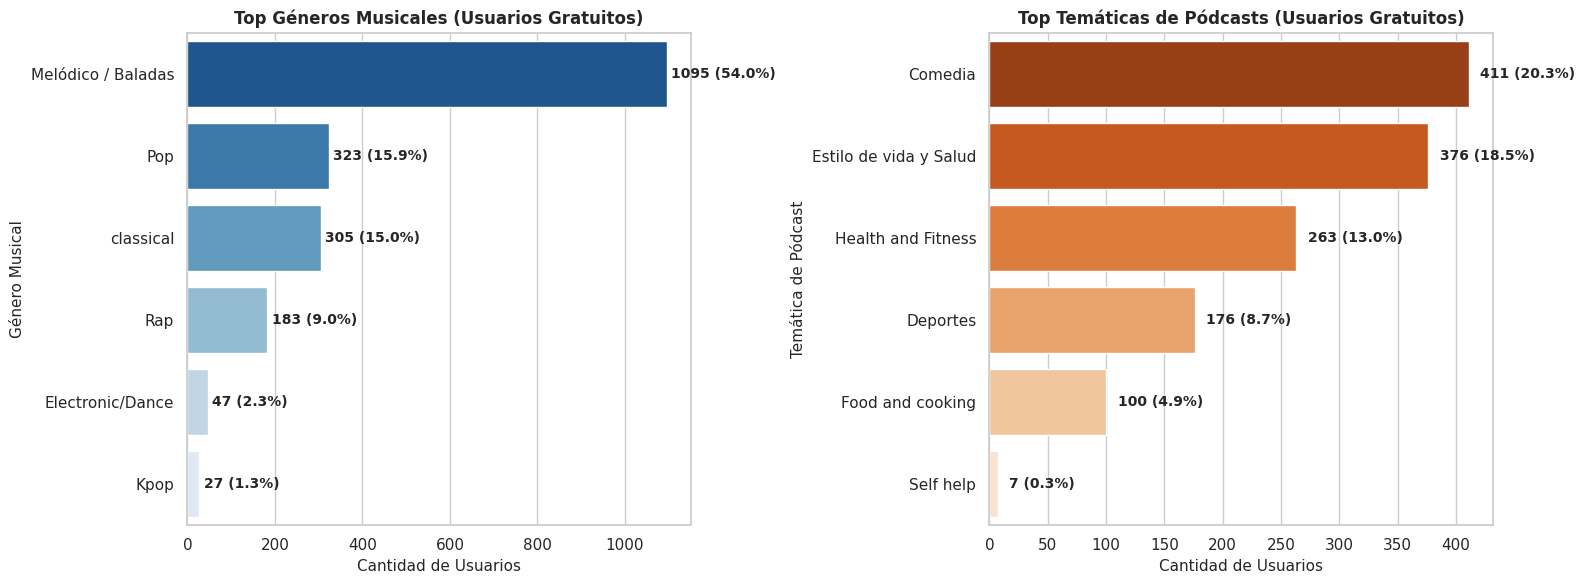

In [14]:
# 1. Configurar panel con dos gráficos de barras horizontales
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 2. Gráfico A: Top Géneros Musicales
top_musica = df_free['Genero_Musical_Favorito'].value_counts().head(6)
ax1 = sns.barplot(
    x=top_musica.values,
    y=top_musica.index,
    palette='Blues_r',
    ax=axes[0]
)
axes[0].set_title('Top Géneros Musicales (Usuarios Gratuitos)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Cantidad de Usuarios', fontsize=11)
axes[0].set_ylabel('Género Musical', fontsize=11)

# Etiquetas numéricas y porcentuales sobre el total de usuarios gratuitos
total_free = len(df_free)
for p in ax1.patches:
    ancho = p.get_width()
    ax1.annotate(f'{int(ancho)} ({ancho/total_free*100:.1f}%)',
                 (ancho + 10, p.get_y() + p.get_height() / 2.),
                 ha='left', va='center', fontsize=10, fontweight='bold')

# 3. Gráfico B: Top Temáticas de Pódcasts
top_podcast = df_free['Genero_Podcast_Favorito'].value_counts().head(6)
ax2 = sns.barplot(
    x=top_podcast.values,
    y=top_podcast.index,
    palette='Oranges_r',
    ax=axes[1]
)
axes[2] if False else None
axes[1].set_title('Top Temáticas de Pódcasts (Usuarios Gratuitos)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Cantidad de Usuarios', fontsize=11)
axes[1].set_ylabel('Temática de Pódcast', fontsize=11)

for p in ax2.patches:
    ancho = p.get_width()
    ax2.annotate(f'{int(ancho)} ({ancho/total_free*100:.1f}%)',
                 (ancho + 10, p.get_y() + p.get_height() / 2.),
                 ha='left', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

##algoritmo agrupacion/clustering##
